# Road graph: a simplified map for navigation

**This notebook was written by generative AI. It's a proof of concept that hasn't been validated; use at your own risk.**

If a map's job is to show which roads connect, how far it is from one place to another, and what'll be hard to get an engine through, then exact geography can be more noise than help. This draws the roads around a rural town as a graph -- intersections and dead ends as nodes, the roads between them as edges -- in the spirit of a subway map, rather than as a map ([issue](https://github.com/investinopen/ptps-wildfire-demo/issues/22)).

- Each road is drawn with its length proportional to its driving distance, and labeled with it.
- Roads are colored by their steepest grade, and sharp turns are marked.
- Addresses are placed along their street, at their distance down it, with house numbers where there's room.
- Dead ends, turnarounds, and gates are marked, the same as on the [firefighter map](../firefighter-map/).
- The layout still keeps the rough shape of the area, so places farther north are higher up on the page, and so on.

## Configuration

In [1]:
# a small mountain town west of Boulder, where roads are steep and winding and many homes are down long private drives
PLACE_NAME = "Gold Hill, Colorado"
CENTER = (40.063, -105.409)  # (lat, lon)
RADIUS_METERS = 1200

# fire apparatus access roads "shall not exceed 10 percent in grade" under the International Fire Code (Appendix D103.2), unless the fire code official approves otherwise
MAX_GRADE = 0.10
STEEP_GRADE = 0.15
# grades are measured over this distance, so one noisy elevation sample doesn't read as a cliff
GRADE_SPAN_METERS = 50
# a bend that turns at least this much within TURN_SPAN_METERS on either side gets marked -- roughly a curve tighter than a 30-meter (100-foot) radius
SHARP_TURN_DEGREES = 110
TURN_SPAN_METERS = 30
# same as the firefighter map's dead ends: short driveways can be backed out of, so they're left off
MIN_DRIVEWAY_METERS = 150
# how finely roads are sampled for grades and turns
STEP_METERS = 10

In [2]:
from datetime import UTC, datetime

RUN_AT = datetime.now(UTC)
print("Run time (UTC):", RUN_AT.isoformat(timespec="seconds"))

Run time (UTC): 2026-09-24T04:43:01+00:00


## Road network

Drivable roads from [OpenStreetMap](https://www.openstreetmap.org/copyright), via [OSMnx](https://osmnx.readthedocs.io/). Tracks are included, since engines use them as fire roads. The network is then simplified so the only nodes are intersections, dead ends, and gates, with each stretch of road between two of them as one edge.

In [3]:
import osmnx as ox

# alongside the notebooks' other downloads, which aren't committed
ox.settings.cache_folder = "data_cache/osmnx"
ox.settings.useful_tags_node = ["highway", "barrier"]
ox.settings.useful_tags_way = ["highway", "service", "name", "ref", "surface"]

# the same highway types as DRIVABLE_HIGHWAYS in the firefighter map, minus parking lot aisles and drive-throughs
# https://wiki.openstreetmap.org/wiki/Key:highway
DRIVABLE_FILTER = (
    '["highway"~"^(motorway|motorway_link|trunk|trunk_link|primary|primary_link|secondary|secondary_link|tertiary|tertiary_link|unclassified|residential|living_street|service|track)$"]'
    '["service"!~"^(parking_aisle|parking|drive-through)$"]'
    '["area"!="yes"]'
)
# barriers an engine can't drive through, even when open some of the time -- also the same as the firefighter map's
# https://wiki.openstreetmap.org/wiki/Key:barrier
VEHICLE_BARRIERS = {"gate", "lift_gate", "swing_gate", "chain", "bollard"}
# mapped places to turn around at the end of a road
# https://wiki.openstreetmap.org/wiki/Tag:highway%3Dturning_circle
TURNAROUNDS = {"turning_circle", "turning_loop"}

raw = ox.graph_from_point(
    CENTER,
    dist=RADIUS_METERS,
    custom_filter=DRIVABLE_FILTER,
    simplify=False,
    # keeps roads that leave the area running to the next intersection, rather than stopping at the edge
    truncate_by_edge=True,
)
# only vehicle barriers should survive simplification as nodes of their own (see below)
for _, data in raw.nodes(data=True):
    if data.get("barrier") not in VEHICLE_BARRIERS:
        data.pop("barrier", None)
G = ox.simplify_graph(raw, node_attrs_include=["barrier"])
# which roads connect matters here, not which way they're drawn -- one-way roads are rare out here
G = ox.convert.to_undirected(ox.project_graph(G))
print(f"{len(G.nodes):,} nodes, {len(G.edges):,} edges")

164 nodes, 181 edges


Short driveways that just lead to one house are left off, since they'd outnumber the roads. Removing them leaves nodes where only two roads meet, so those are merged back into single edges.

In [4]:
from shapely import LineString
from shapely.ops import linemerge


def is_short_driveway(u, v, data):
    return (
        data.get("service") == "driveway"
        and data["length"] < MIN_DRIVEWAY_METERS
        and min(G.degree(u), G.degree(v)) == 1
    )


def edge_line(G, u, v, data):
    """The edge's geometry, running from u to v."""
    line = data.get("geometry") or LineString(
        [(G.nodes[n]["x"], G.nodes[n]["y"]) for n in (u, v)]
    )
    start = line.coords[0]
    if (start[0], start[1]) != (G.nodes[u]["x"], G.nodes[u]["y"]):
        line = line.reverse()
    return line


def first(value):
    """OSMnx keeps a list when the ways it merged disagree."""
    return value[0] if isinstance(value, list) else value


def merge_through_nodes(G):
    """Joins the two edges at every node that's only between two roads, and isn't a gate or turnaround."""
    for node in list(G.nodes):
        if G.degree(node) != 2 or "barrier" in G.nodes[node]:
            continue
        (_, a, _ka, da), (_, b, _kb, db) = G.edges(node, keys=True, data=True)
        if a == node or b == node or a == b:  # a loop
            continue
        line = linemerge([edge_line(G, a, node, da), edge_line(G, node, b, db)])
        merged = {
            **da,
            "geometry": line,
            "length": da["length"] + db["length"],
            # the longer piece's name/class wins, e.g. a road with a short named spur
            **{
                k: first(max((da, db), key=lambda d: d["length"]).get(k))
                for k in ("name", "highway", "service", "ref")
            },
        }
        G.remove_node(node)
        G.add_edge(a, b, **merged)


G.remove_edges_from(
    [
        (u, v, k)
        for u, v, k, d in G.edges(keys=True, data=True)
        if is_short_driveway(u, v, d)
    ]
)
G.remove_nodes_from([n for n in list(G.nodes) if G.degree(n) == 0])
merge_through_nodes(G)
for _, _, data in G.edges(data=True):
    for k in ("name", "highway", "service", "ref"):
        data[k] = first(data.get(k))
print(f"{len(G.nodes):,} nodes, {len(G.edges):,} edges")

99 nodes, 116 edges


## Elevation

From [Mapterhorn](https://mapterhorn.com/)'s open terrain tiles -- the same ones behind the firefighter map's topographic shading, which in the US come from the USGS's [3D Elevation Program](https://www.usgs.gov/3d-elevation-program).

In [5]:
import io

import httpx
import numpy as np
from PIL import Image
from pyproj import Transformer

TILE_URL = "https://tiles.mapterhorn.com/{z}/{x}/{y}.webp"
TILE_SIZE = 512
TILE_ZOOM = 14  # ~5 meters per pixel at this latitude, finer than the grade span


def lonlat_to_pixel(lon, lat, zoom=TILE_ZOOM):
    """Global pixel coordinates at `zoom`, in Web Mercator."""
    scale = TILE_SIZE * 2**zoom
    x = (lon + 180) / 360 * scale
    y = (1 - np.arcsinh(np.tan(np.radians(lat))) / np.pi) / 2 * scale
    return x, y


to_lonlat = Transformer.from_crs(G.graph["crs"], "EPSG:4326", always_xy=True)
lons, lats = to_lonlat.transform(
    [d["x"] for _, d in G.nodes(data=True)], [d["y"] for _, d in G.nodes(data=True)]
)
# a margin, since edges can bulge out past their end nodes
px_min = lonlat_to_pixel(min(lons) - 0.01, max(lats) + 0.01)
px_max = lonlat_to_pixel(max(lons) + 0.01, min(lats) - 0.01)
tx_range = range(int(px_min[0] // TILE_SIZE), int(px_max[0] // TILE_SIZE) + 1)
ty_range = range(int(px_min[1] // TILE_SIZE), int(px_max[1] // TILE_SIZE) + 1)

dem = np.zeros((len(ty_range) * TILE_SIZE, len(tx_range) * TILE_SIZE))
with httpx.Client(timeout=30) as client:
    for j, ty in enumerate(ty_range):
        for i, tx in enumerate(tx_range):
            response = client.get(TILE_URL.format(z=TILE_ZOOM, x=tx, y=ty))
            response.raise_for_status()
            rgb = np.asarray(Image.open(io.BytesIO(response.content)).convert("RGB"))
            # https://github.com/tilezen/joerd/blob/master/docs/formats.md#terrarium
            r, g, b = (rgb[..., c].astype(float) for c in range(3))
            dem[
                j * TILE_SIZE : (j + 1) * TILE_SIZE, i * TILE_SIZE : (i + 1) * TILE_SIZE
            ] = r * 256 + g + b / 256 - 32768
DEM_ORIGIN = (tx_range.start * TILE_SIZE, ty_range.start * TILE_SIZE)


def elevations(xs, ys):
    """Elevation in meters at projected points, bilinearly interpolated."""
    lon, lat = to_lonlat.transform(xs, ys)
    px, py = lonlat_to_pixel(np.asarray(lon), np.asarray(lat))
    # pixel centers are at +0.5
    px = px - DEM_ORIGIN[0] - 0.5
    py = py - DEM_ORIGIN[1] - 0.5
    x0, y0 = np.floor(px).astype(int), np.floor(py).astype(int)
    fx, fy = px - x0, py - y0
    return (
        dem[y0, x0] * (1 - fx) * (1 - fy)
        + dem[y0, x0 + 1] * fx * (1 - fy)
        + dem[y0 + 1, x0] * (1 - fx) * fy
        + dem[y0 + 1, x0 + 1] * fx * fy
    )


print(f"{len(tx_range) * len(ty_range)} tiles, {dem.min():.0f}-{dem.max():.0f} m")

12 tiles, 2054-2720 m


## Grades and sharp turns

Each road is sampled every few meters along its length. Its grade is the steepest climb over any `GRADE_SPAN_METERS` stretch, and a sharp turn is anywhere its heading changes by at least `SHARP_TURN_DEGREES` from `TURN_SPAN_METERS` before to `TURN_SPAN_METERS` after -- the tightest spot of each bend is marked.

In [6]:
GRADE_STEPS = GRADE_SPAN_METERS // STEP_METERS
TURN_STEPS = TURN_SPAN_METERS // STEP_METERS


def sample(line):
    distances = np.arange(0, line.length, STEP_METERS)
    distances = np.append(distances, line.length)
    points = [line.interpolate(d) for d in distances]
    return distances, np.array([p.x for p in points]), np.array([p.y for p in points])


def max_grade(xs, ys, elev):
    if len(elev) <= GRADE_STEPS:
        run = np.hypot(xs[-1] - xs[0], ys[-1] - ys[0])
        return abs(elev[-1] - elev[0]) / run if run else 0
    rise = np.abs(elev[GRADE_STEPS:] - elev[:-GRADE_STEPS])
    return rise.max() / GRADE_SPAN_METERS


def sharp_turns(distances, xs, ys):
    """Distances along the line of the tightest point of each sharp bend."""
    n = len(xs)
    if n <= 2 * TURN_STEPS:
        return []
    i = np.arange(TURN_STEPS, n - TURN_STEPS)
    before = np.arctan2(ys[i] - ys[i - TURN_STEPS], xs[i] - xs[i - TURN_STEPS])
    after = np.arctan2(ys[i + TURN_STEPS] - ys[i], xs[i + TURN_STEPS] - xs[i])
    turn = np.degrees(np.abs((after - before + np.pi) % (2 * np.pi) - np.pi))
    turns = []
    # walk each run of sharp samples, and keep its sharpest
    sharp = turn >= SHARP_TURN_DEGREES
    start = None
    for k in range(len(turn) + 1):
        if k < len(turn) and sharp[k]:
            start = k if start is None else start
        elif start is not None:
            best = start + int(np.argmax(turn[start:k]))
            turns.append(distances[i[best]])
            start = None
    return turns


for u, v, data in G.edges(data=True):
    line = edge_line(G, u, v, data)
    data["geometry"] = line
    distances, xs, ys = sample(line)
    elev = elevations(xs, ys)
    data["grade"] = max_grade(xs, ys, elev)
    # as a fraction of the way from u to v, for placing on the diagram
    data["turns"] = [d / line.length for d in sharp_turns(distances, xs, ys)]
    data["from"] = u

steep = sum(data["grade"] >= MAX_GRADE for _, _, data in G.edges(data=True))
print(f"{steep} of {len(G.edges)} roads are steeper than {MAX_GRADE:.0%} somewhere")
print(f"{sum(len(data['turns']) for _, _, data in G.edges(data=True))} sharp turns")

50 of 116 roads are steeper than 10% somewhere
13 sharp turns


## Addresses

Addresses from OpenStreetMap -- mapped on the house, or on the building itself -- are placed along the road they're on (their `addr:street`), at the point on that road closest to them. That makes each one a stop along the road, so the diagram shows how far down the road it is. Addresses with no street, or none that matches a road here, go on the closest road. A house down one of the long driveways still on the diagram goes on the driveway instead, when the driveway comes off its street, since that's where it's reached from.

In [7]:
# how far an address can be from its road; beyond this, it's left off
MAX_ADDRESS_METERS = 300

addresses = ox.features_from_point(
    CENTER, tags={"addr:housenumber": True}, dist=RADIUS_METERS
).to_crs(G.graph["crs"])
# buildings/lots are mapped as areas
addresses["geometry"] = addresses.geometry.representative_point()

for _, _, data in G.edges(data=True):
    data["addresses"] = []
placed = on_driveways = 0
for point, street, number in zip(
    addresses.geometry, addresses["addr:street"], addresses["addr:housenumber"]
):
    candidates = [
        (data["geometry"].distance(point), (u, v), data)
        for u, v, data in G.edges(data=True)
    ]
    on_street = [c for c in candidates if c[2]["name"] == street]
    distance, _, data = min(on_street or candidates, key=lambda c: c[0])
    nearest_distance, ends, nearest = min(candidates, key=lambda c: c[0])
    street_nodes = {n for _, (u, v), _ in on_street for n in (u, v)}
    if (
        nearest["highway"] == "service"
        and nearest_distance < distance
        and street_nodes.intersection(ends)
    ):
        distance, data = nearest_distance, nearest
        on_driveways += 1
    if distance > MAX_ADDRESS_METERS:
        continue
    line = data["geometry"]
    # as a fraction of the way from the edge's "from" node, like the sharp turns
    data["addresses"].append((line.project(point) / line.length, number))
    placed += 1
print(
    f"{placed} of {len(addresses)} addresses placed, {on_driveways} of them on driveways"
)

153 of 156 addresses placed, 11 of them on driveways


## Layout

Rather than where they are on the ground, intersections are placed so that each road's length on the page is proportional to its driving distance -- a curvy half mile and a straight half mile come out the same length. Roads are drawn straight wherever that works out, and as arcs where they can't be (two roads between the same intersections, or a loop).

Positions start out geographic, then are adjusted to fit the road lengths, balanced against two weaker pulls:

- toward each intersection's actual location, so that places farther north stay higher up on the page (and farther east stay farther right) -- the diagram keeps the rough shape of the area, just not its exact distances
- toward keeping every pair of intersections as far apart as the driving distance between them, so unconnected roads don't pile up on each other

In [8]:
import networkx as nx
from scipy.optimize import minimize

# how much each of the weaker pulls counts, relative to roads' lengths -- higher keeps closer to the actual geography / spreads the diagram out more evenly, at the cost of roads' lengths being less exact
GEOGRAPHY_WEIGHT = 0.001
SPACING_WEIGHT = 0.001

# the shortest road between each pair of intersections sets how far apart they are; any others get drawn as arcs
simple = nx.Graph()
for u, v, data in G.edges(data=True):
    if u != v and (
        not simple.has_edge(u, v) or data["length"] < simple[u][v]["length"]
    ):
        simple.add_edge(u, v, length=data["length"])

nodes = list(simple.nodes)
index = {n: i for i, n in enumerate(nodes)}
edge_i = np.array([index[u] for u, v in simple.edges])
edge_j = np.array([index[v] for u, v in simple.edges])
edge_length = np.array([d["length"] for _, _, d in simple.edges(data=True)])
pair_i, pair_j = np.triu_indices(len(nodes), 1)
pair_distance = nx.floyd_warshall_numpy(simple, nodelist=nodes, weight="length")[
    pair_i, pair_j
]


geographic = np.array([(G.nodes[n]["x"], G.nodes[n]["y"]) for n in nodes])
typical_length = np.median(edge_length)


def stress(flat):
    """How far off each road's length (and, weakly, each intersection's location and each pair's spacing) is, relative to its target -- and its gradient."""
    X = flat.reshape(-1, 2)
    moved = (X - geographic) / typical_length
    total = GEOGRAPHY_WEIGHT * (moved**2).sum()
    gradient = 2 * GEOGRAPHY_WEIGHT * moved / typical_length
    for i, j, target, weight in (
        (edge_i, edge_j, edge_length, 1),
        (pair_i, pair_j, pair_distance, SPACING_WEIGHT),
    ):
        delta = X[i] - X[j]
        actual = np.hypot(delta[:, 0], delta[:, 1]) + 1e-9
        error = (actual - target) / target
        total += weight * (error**2).sum()
        g = (2 * weight * error / target / actual)[:, None] * delta
        np.add.at(gradient, i, g)
        np.add.at(gradient, j, -g)
    return total, gradient.ravel()


result = minimize(stress, geographic.ravel(), jac=True, method="L-BFGS-B")
pos = dict(zip(nodes, result.x.reshape(-1, 2)))

drawn = np.hypot(*(result.x.reshape(-1, 2)[edge_i] - result.x.reshape(-1, 2)[edge_j]).T)
off = np.abs(drawn / edge_length - 1)
print(
    f"Road lengths on the page are within {np.percentile(off, 95):.0%} of scale for 95% of roads, and {off.max():.0%} at worst"
)

# of the pairs of intersections at least 100 m apart north-south (or east-west), how many ended up the other way around on the page
for axis, direction in ((1, "north-south"), (0, "east-west")):
    actual = geographic[pair_i, axis] - geographic[pair_j, axis]
    drawn_ = (
        result.x.reshape(-1, 2)[pair_i, axis] - result.x.reshape(-1, 2)[pair_j, axis]
    )
    apart = np.abs(actual) >= 100
    flipped = np.mean(np.sign(actual[apart]) != np.sign(drawn_[apart]))
    print(f"{flipped:.1%} of intersections are out of order {direction}")

Road lengths on the page are within 2% of scale for 95% of roads, and 5% at worst
1.0% of intersections are out of order north-south
0.6% of intersections are out of order east-west


## Diagram

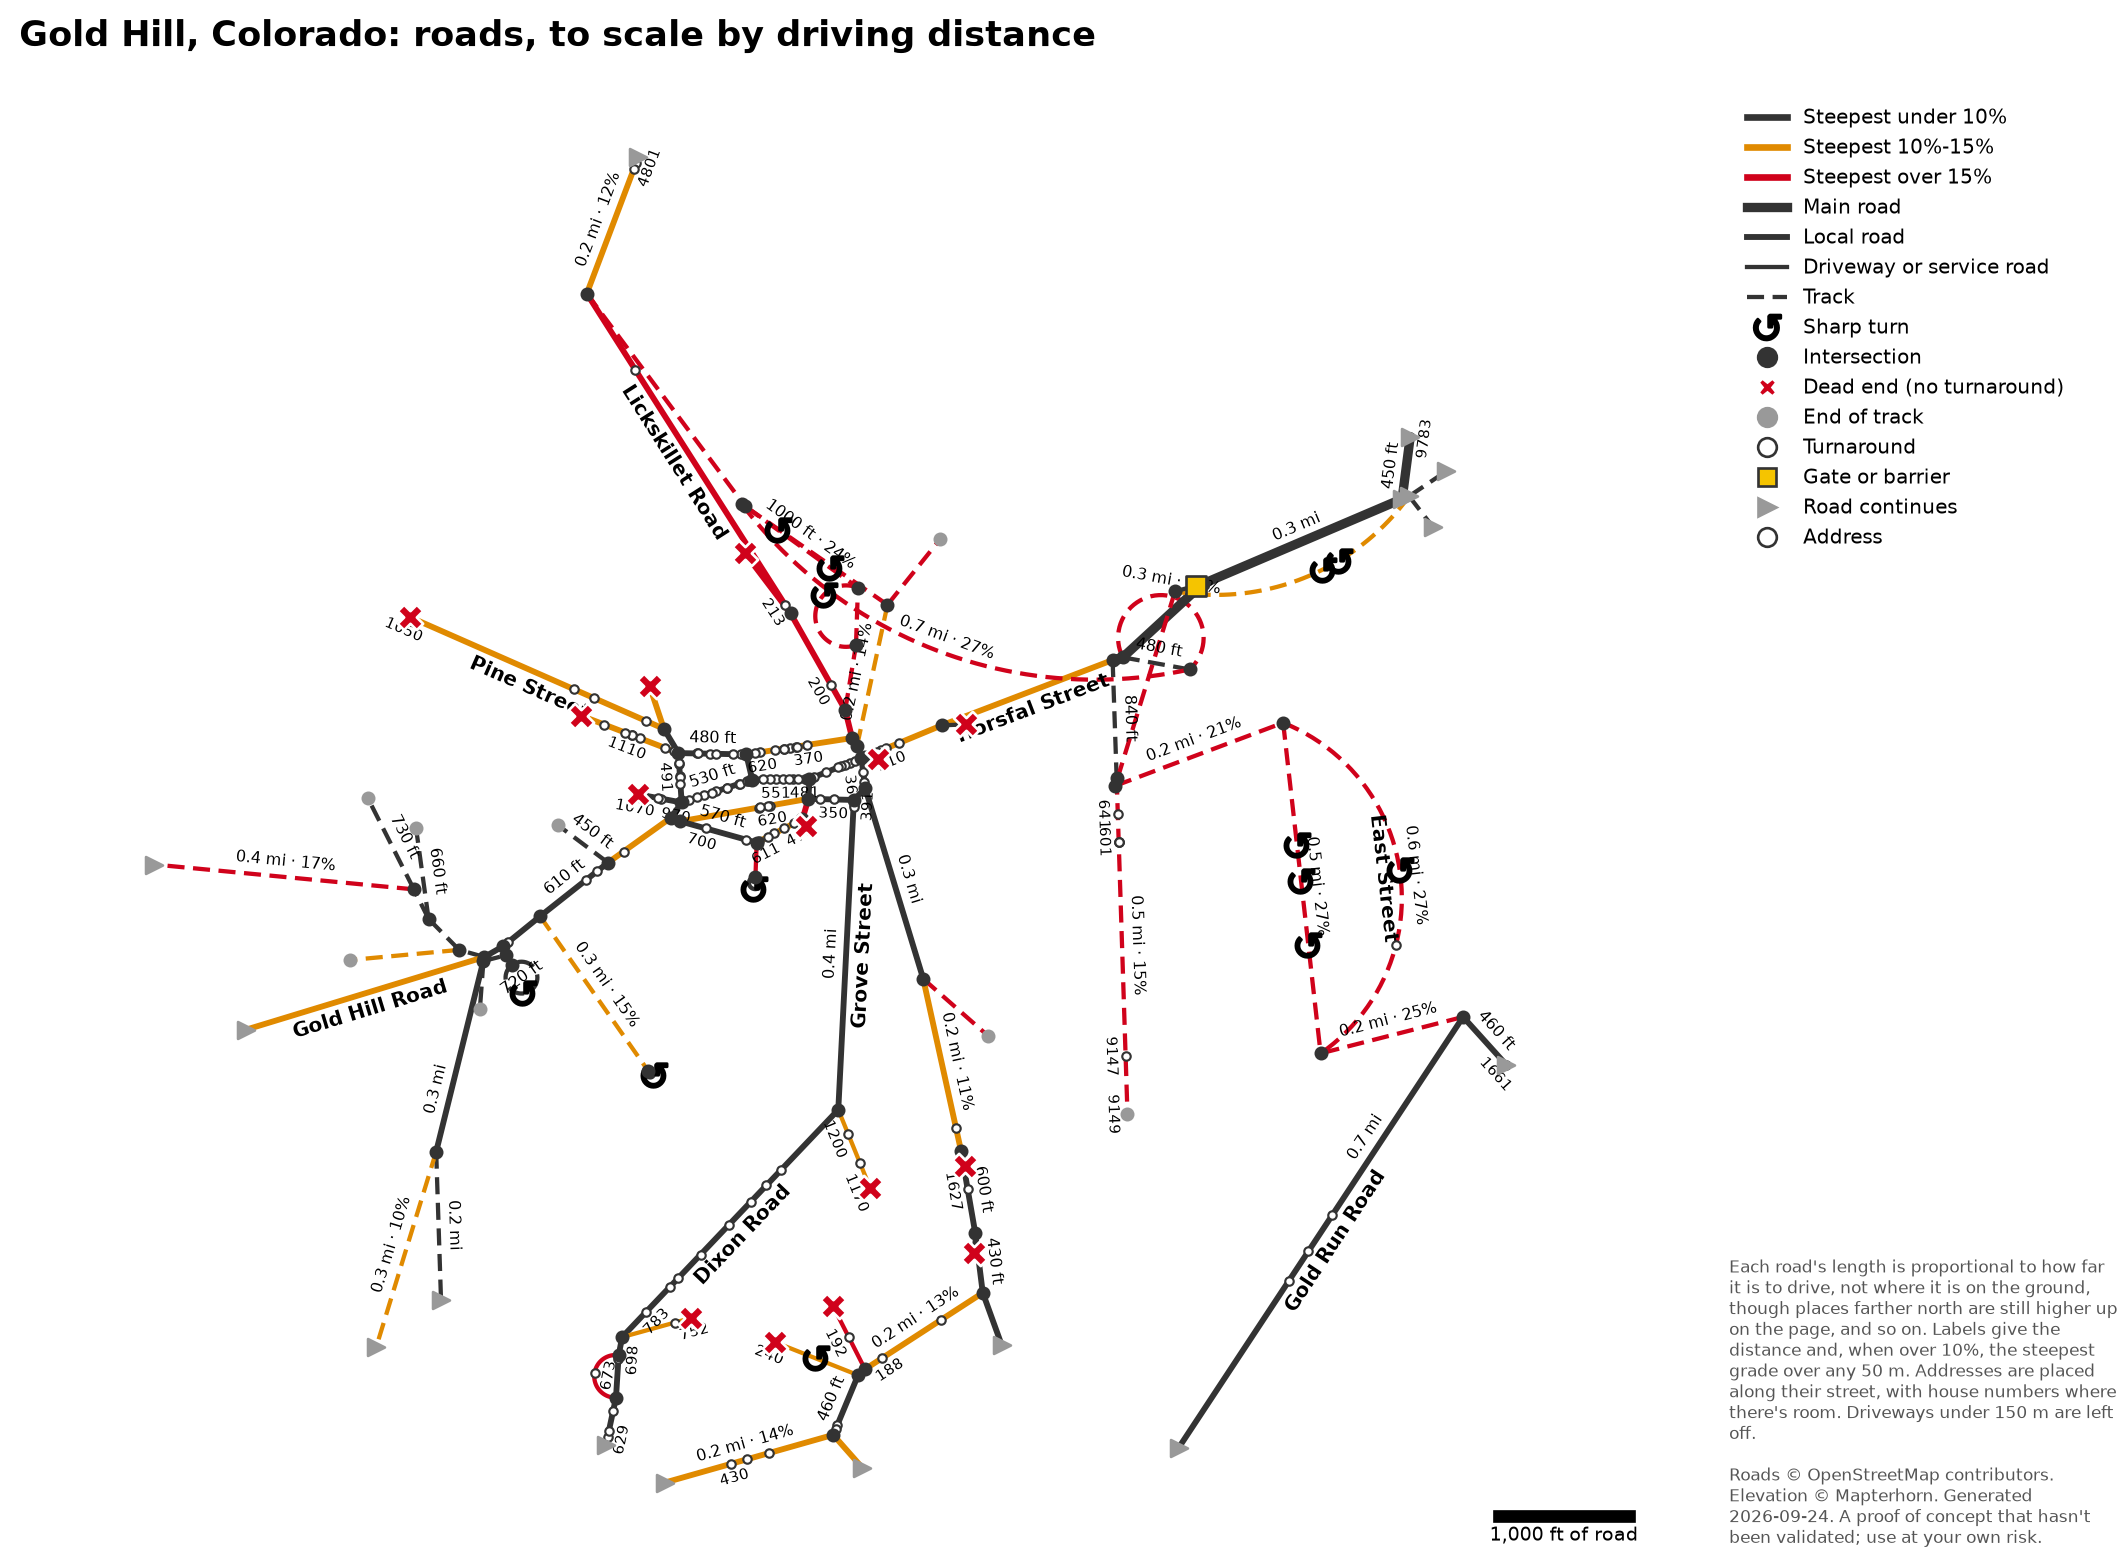

In [9]:
import math

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
from scipy.optimize import brentq
from shapely import Point

FEET_PER_METER = 3.28084
FEET_PER_MILE = 5280

# drawn thicker the bigger the road
WIDTHS = {"track": 1.6, "service": 1.6, "residential": 2.2, "unclassified": 2.2}
MAJOR_WIDTH = 3.5
GRADE_COLORS = [
    (MAX_GRADE, "#333333", f"under {MAX_GRADE:.0%}"),
    (STEEP_GRADE, "#e08a00", f"{MAX_GRADE:.0%}-{STEEP_GRADE:.0%}"),
    (math.inf, "#d0021b", f"over {STEEP_GRADE:.0%}"),
]
TURN_MARKER = "$↺$"


def grade_color(grade):
    return next(color for limit, color, _ in GRADE_COLORS if grade < limit)


def format_distance(meters):
    feet = meters * FEET_PER_METER
    if feet < 1000:
        return f"{round(feet, -1):.0f} ft"
    return f"{feet / FEET_PER_MILE:.1f} mi"


def upright(degrees):
    """Keeps text along a line from reading upside down."""
    return (degrees + 90) % 180 - 90


def arc(p0, p1, length, side=1):
    """Points from p0 to p1: a straight line if that's about the right length, otherwise a circular arc `length` long, bowed to `side` (1 or -1)."""
    chord = np.linalg.norm(p1 - p0)
    if length <= chord * 1.05:
        return np.array([p0, p1])
    # the angle the arc sweeps: length / chord = (angle / 2) / sin(angle / 2)
    sweep = brentq(
        lambda a: a / 2 / math.sin(a / 2) - length / chord, 1e-6, 2 * math.pi - 1e-6
    )
    radius = chord / 2 / math.sin(sweep / 2)
    mid = (p0 + p1) / 2
    normal = np.array([-(p1 - p0)[1], (p1 - p0)[0]]) / chord
    center = mid - side * normal * radius * math.cos(sweep / 2)
    start = math.atan2(*(p0 - center)[::-1])
    t = np.linspace(0, 1, 50)
    angles = start - side * sweep * t
    return center + radius * np.column_stack([np.cos(angles), np.sin(angles)])


def loop(p, length, away):
    """A circle `length` around that starts and ends at p, on the side facing `away`."""
    radius = length / (2 * math.pi)
    center = p + away / np.linalg.norm(away) * radius
    start = math.atan2(*(p - center)[::-1])
    angles = start + np.linspace(0, 2 * math.pi, 50)
    return center + radius * np.column_stack([np.cos(angles), np.sin(angles)])


def along(points, fraction):
    """The point `fraction` of the way along a polyline, and its direction in degrees there."""
    steps = np.hypot(*np.diff(points, axis=0).T)
    target = fraction * steps.sum()
    k = min(np.searchsorted(np.cumsum(steps), target), len(steps) - 1)
    t = (target - steps[:k].sum()) / steps[k]
    dx, dy = points[k + 1] - points[k]
    return points[k] + t * (points[k + 1] - points[k]), math.degrees(math.atan2(dy, dx))


to_projected = Transformer.from_crs("EPSG:4326", G.graph["crs"], always_xy=True)
CENTER_POINT = Point(*to_projected.transform(CENTER[1], CENTER[0]))


def node_kind(node, data):
    if "barrier" in data:
        return "gate"
    if CENTER_POINT.distance(Point(data["x"], data["y"])) > RADIUS_METERS:
        return "continues"
    if G.degree(node) == 1:
        if data.get("highway") in TURNAROUNDS:
            return "turnaround"
        ((_, _, road),) = G.edges(node, data=True)
        # like the firefighter map, tracks aren't flagged, since they routinely end at trails
        return "track end" if road["highway"] == "track" else "dead end"
    return "intersection"


NODE_STYLES = {
    "intersection": {
        "marker": "o",
        "s": 18,
        "color": "#333333",
        "label": "Intersection",
    },
    "dead end": {
        "marker": "X",
        "s": 90,
        "color": "#d0021b",
        "edgecolor": "white",
        "label": "Dead end (no turnaround)",
    },
    "track end": {"marker": "o", "s": 18, "color": "#999999", "label": "End of track"},
    "turnaround": {
        "marker": "o",
        "s": 60,
        "facecolor": "white",
        "edgecolor": "#333333",
        "linewidth": 1.5,
        "label": "Turnaround",
    },
    "gate": {
        "marker": "s",
        "s": 60,
        "color": "#f5c400",
        "edgecolor": "#333333",
        "label": "Gate or barrier",
    },
    "continues": {
        "marker": ">",
        "s": 40,
        "color": "#999999",
        "label": "Road continues",
    },
}

# each road's path on the page, running from its "from" node
paths = {}
parallels = {}
for u, v, k, data in G.edges(keys=True, data=True):
    a, b = data["from"], v if data["from"] == u else u
    if a == b:
        neighbors = [pos[n] for n in G.neighbors(a) if n != a]
        away = pos[a] - np.mean(neighbors, axis=0) if neighbors else np.array([0, 1])
        paths[u, v, k] = loop(pos[a], data["length"], away)
    else:
        pair = tuple(sorted((a, b)))
        side = 1 if parallels.get(pair, 0) % 2 == 0 else -1
        parallels[pair] = parallels.get(pair, 0) + 1
        paths[u, v, k] = arc(
            pos[a], pos[b], data["length"], side if a == pair[0] else -side
        )

kinds = {n: node_kind(n, d) for n, d in G.nodes(data=True)}

SCALE_BAR_FEET = [100, 250, 500, 1000, 2500, 5000]
# roughly how wide a character of the labels is, in points, for deciding whether a label fits along its road
CHAR_POINTS = {5.5: 3.3, 6: 3.6, 7.5: 4.8}
ADDRESS_STYLE = {
    "marker": "o",
    "s": 10,
    "facecolor": "white",
    "edgecolor": "#333333",
    "linewidth": 0.8,
}
LEGEND = (
    [
        Line2D([], [], color=color, linewidth=2.5, label=f"Steepest {label}")
        for _, color, label in GRADE_COLORS
    ]
    + [
        Line2D([], [], color="#333333", linewidth=MAJOR_WIDTH, label="Main road"),
        Line2D([], [], color="#333333", linewidth=2.2, label="Local road"),
        Line2D(
            [], [], color="#333333", linewidth=1.6, label="Driveway or service road"
        ),
        Line2D(
            [], [], color="#333333", linewidth=1.6, linestyle=(0, (4, 2)), label="Track"
        ),
        Line2D(
            [],
            [],
            marker=TURN_MARKER,
            markersize=10,
            color="black",
            linestyle="",
            label="Sharp turn",
        ),
    ]
    + [
        Line2D(
            [],
            [],
            marker=s["marker"],
            linestyle="",
            markersize=7,
            markerfacecolor=s.get("facecolor", s.get("color")),
            markeredgecolor=s.get("edgecolor", s.get("color")),
            label=s["label"],
        )
        for s in [*NODE_STYLES.values(), {**ADDRESS_STYLE, "label": "Address"}]
    ]
)


def draw(title, bounds=None):
    """One US Letter landscape page, for printing, with the legend in its own column. `bounds` is (xmin, ymin, xmax, ymax) in layout coordinates, or the whole network if None."""
    fig, (ax, key) = plt.subplots(1, 2, figsize=(11, 8.5), width_ratios=[5, 1])
    # fills the page, showing extra around `bounds` rather than shrinking to fit it exactly
    ax.set_aspect("equal", adjustable="datalim")
    ax.set_axis_off()
    ax.set_title(title, loc="left", fontsize=13, fontweight="bold")

    for (u, v, k), points in paths.items():
        data = G.edges[u, v, k]
        ax.plot(
            *points.T,
            color=grade_color(data["grade"]),
            linewidth=WIDTHS.get(data["highway"], MAJOR_WIDTH),
            linestyle=(0, (4, 2)) if data["highway"] == "track" else "-",
            solid_capstyle="round",
            zorder=1,
        )
        for fraction in data["turns"]:
            (x, y), _ = along(points, fraction)
            ax.scatter(x, y, marker=TURN_MARKER, s=90, color="black", zorder=4)
        for fraction, _ in data["addresses"]:
            (x, y), _ = along(points, fraction)
            ax.scatter(x, y, zorder=4, **ADDRESS_STYLE)
    for kind, style in NODE_STYLES.items():
        shown = [pos[n] for n, k in kinds.items() if k == kind]
        if shown:
            ax.scatter(*np.array(shown).T, zorder=5, **style)

    fig.tight_layout()
    if bounds is not None:
        # widened to the shape of the space on the page, so it's filled
        xmin, ymin, xmax, ymax = bounds
        box = ax.get_window_extent()
        page_ratio = box.height / box.width
        if (ymax - ymin) / (xmax - xmin) < page_ratio:
            pad = ((xmax - xmin) * page_ratio - (ymax - ymin)) / 2
            ymin, ymax = ymin - pad, ymax + pad
        else:
            pad = ((ymax - ymin) / page_ratio - (xmax - xmin)) / 2
            xmin, xmax = xmin - pad, xmax + pad
        ax.set_adjustable("box")
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)
    # so the transform below reflects the final limits
    fig.canvas.draw()
    points_per_meter = (
        (ax.transData.transform((1, 0))[0] - ax.transData.transform((0, 0))[0])
        * 72
        / fig.dpi
    )

    renderer = fig.canvas.get_renderer()
    # the space each label takes up, so later ones don't land on top of it
    taken = []

    def label(points, text, fontsize, side, fractions=(0.5, 0.3, 0.7), fits=None):
        """Along the road, just above (side=1) or below (side=-1) it -- if the road's long enough to fit it (or `fits` says so) -- at the first of `fractions` of the way along where it's clear of the other labels."""
        length = np.hypot(*np.diff(points, axis=0).T).sum() * points_per_meter
        if fits is None:
            fits = len(text) * CHAR_POINTS[fontsize] <= length
        if not fits:
            return
        for fraction in fractions:
            if place(points, text, fontsize, side, fraction):
                return

    def place(points, text, fontsize, side, fraction):
        (x, y), angle = along(points, fraction)
        angle = upright(angle)
        # clear of the line, rather than covering it
        offset = side * (MAJOR_WIDTH / 2 + 1)
        annotation = ax.annotate(
            text,
            (x, y),
            xytext=(
                -offset * math.sin(math.radians(angle)),
                offset * math.cos(math.radians(angle)),
            ),
            textcoords="offset points",
            rotation=angle,
            rotation_mode="anchor",
            ha="center",
            va="bottom" if side > 0 else "top",
            fontsize=fontsize,
            zorder=3,
            annotation_clip=True,
            fontweight="bold" if fontsize > 6 else "normal",
        )
        extent = annotation.get_window_extent(renderer)
        if any(extent.overlaps(other) for other in taken):
            annotation.remove()
            return False
        taken.append(extent)
        return True

    # placed in order of importance, since a label that'd overlap an earlier one is left off: each road's name once, below its longest stretch, then the distances, then the house numbers
    longest = {}
    for (u, v, k), points in paths.items():
        data = G.edges[u, v, k]
        if data["name"] and data["length"] > longest.get(data["name"], (0,))[0]:
            longest[data["name"]] = (data["length"], points)
    for name, (_, points) in longest.items():
        label(points, name, 7.5, -1)
    for (u, v, k), points in paths.items():
        data = G.edges[u, v, k]
        text = format_distance(data["length"])
        if data["grade"] >= MAX_GRADE:
            text += f" · {data['grade']:.0%}"
        label(points, text, 6, 1)
    for (u, v, k), points in paths.items():
        for fraction, number in G.edges[u, v, k]["addresses"]:
            label(points, number, 5.5, -1, [fraction], fits=True)

    # the longest round length that takes up no more than a sixth of the page
    width = np.diff(ax.get_xlim())[0] * FEET_PER_METER
    scale_feet = max(f for f in SCALE_BAR_FEET if f <= width / 6)
    ax.add_artist(
        AnchoredSizeBar(
            ax.transData,
            scale_feet / FEET_PER_METER,
            f"{scale_feet:,} ft of road",
            "lower right",
            frameon=False,
            size_vertical=0.05 * 72 / points_per_meter,
            fontproperties={"size": 7},
        )
    )
    key.set_axis_off()
    key.legend(handles=LEGEND, loc="upper left", fontsize=7.5, frameon=False)
    key.text(
        0,
        0,
        "Each road's length is proportional to how far it is to drive, not where it is on the ground, though places farther north are still higher up on the page, and so on. "
        f"Labels give the distance and, when over {MAX_GRADE:.0%}, the steepest grade over any {GRADE_SPAN_METERS} m. "
        "Addresses are placed along their street, with house numbers where there's room. "
        f"Driveways under {MIN_DRIVEWAY_METERS} m are left off.\n\n"
        f"Roads © OpenStreetMap contributors. Elevation © Mapterhorn. Generated {RUN_AT:%Y-%m-%d}. "
        "A proof of concept that hasn't been validated; use at your own risk.",
        fontsize=6.5,
        color="#555555",
        va="bottom",
        wrap=True,
        transform=key.transAxes,
    )
    return fig


draw(f"{PLACE_NAME}: roads, to scale by driving distance")
plt.show()

At one scale, the town's short blocks get lost next to the long rural roads, so here's the middle of town on its own page, at a larger scale.

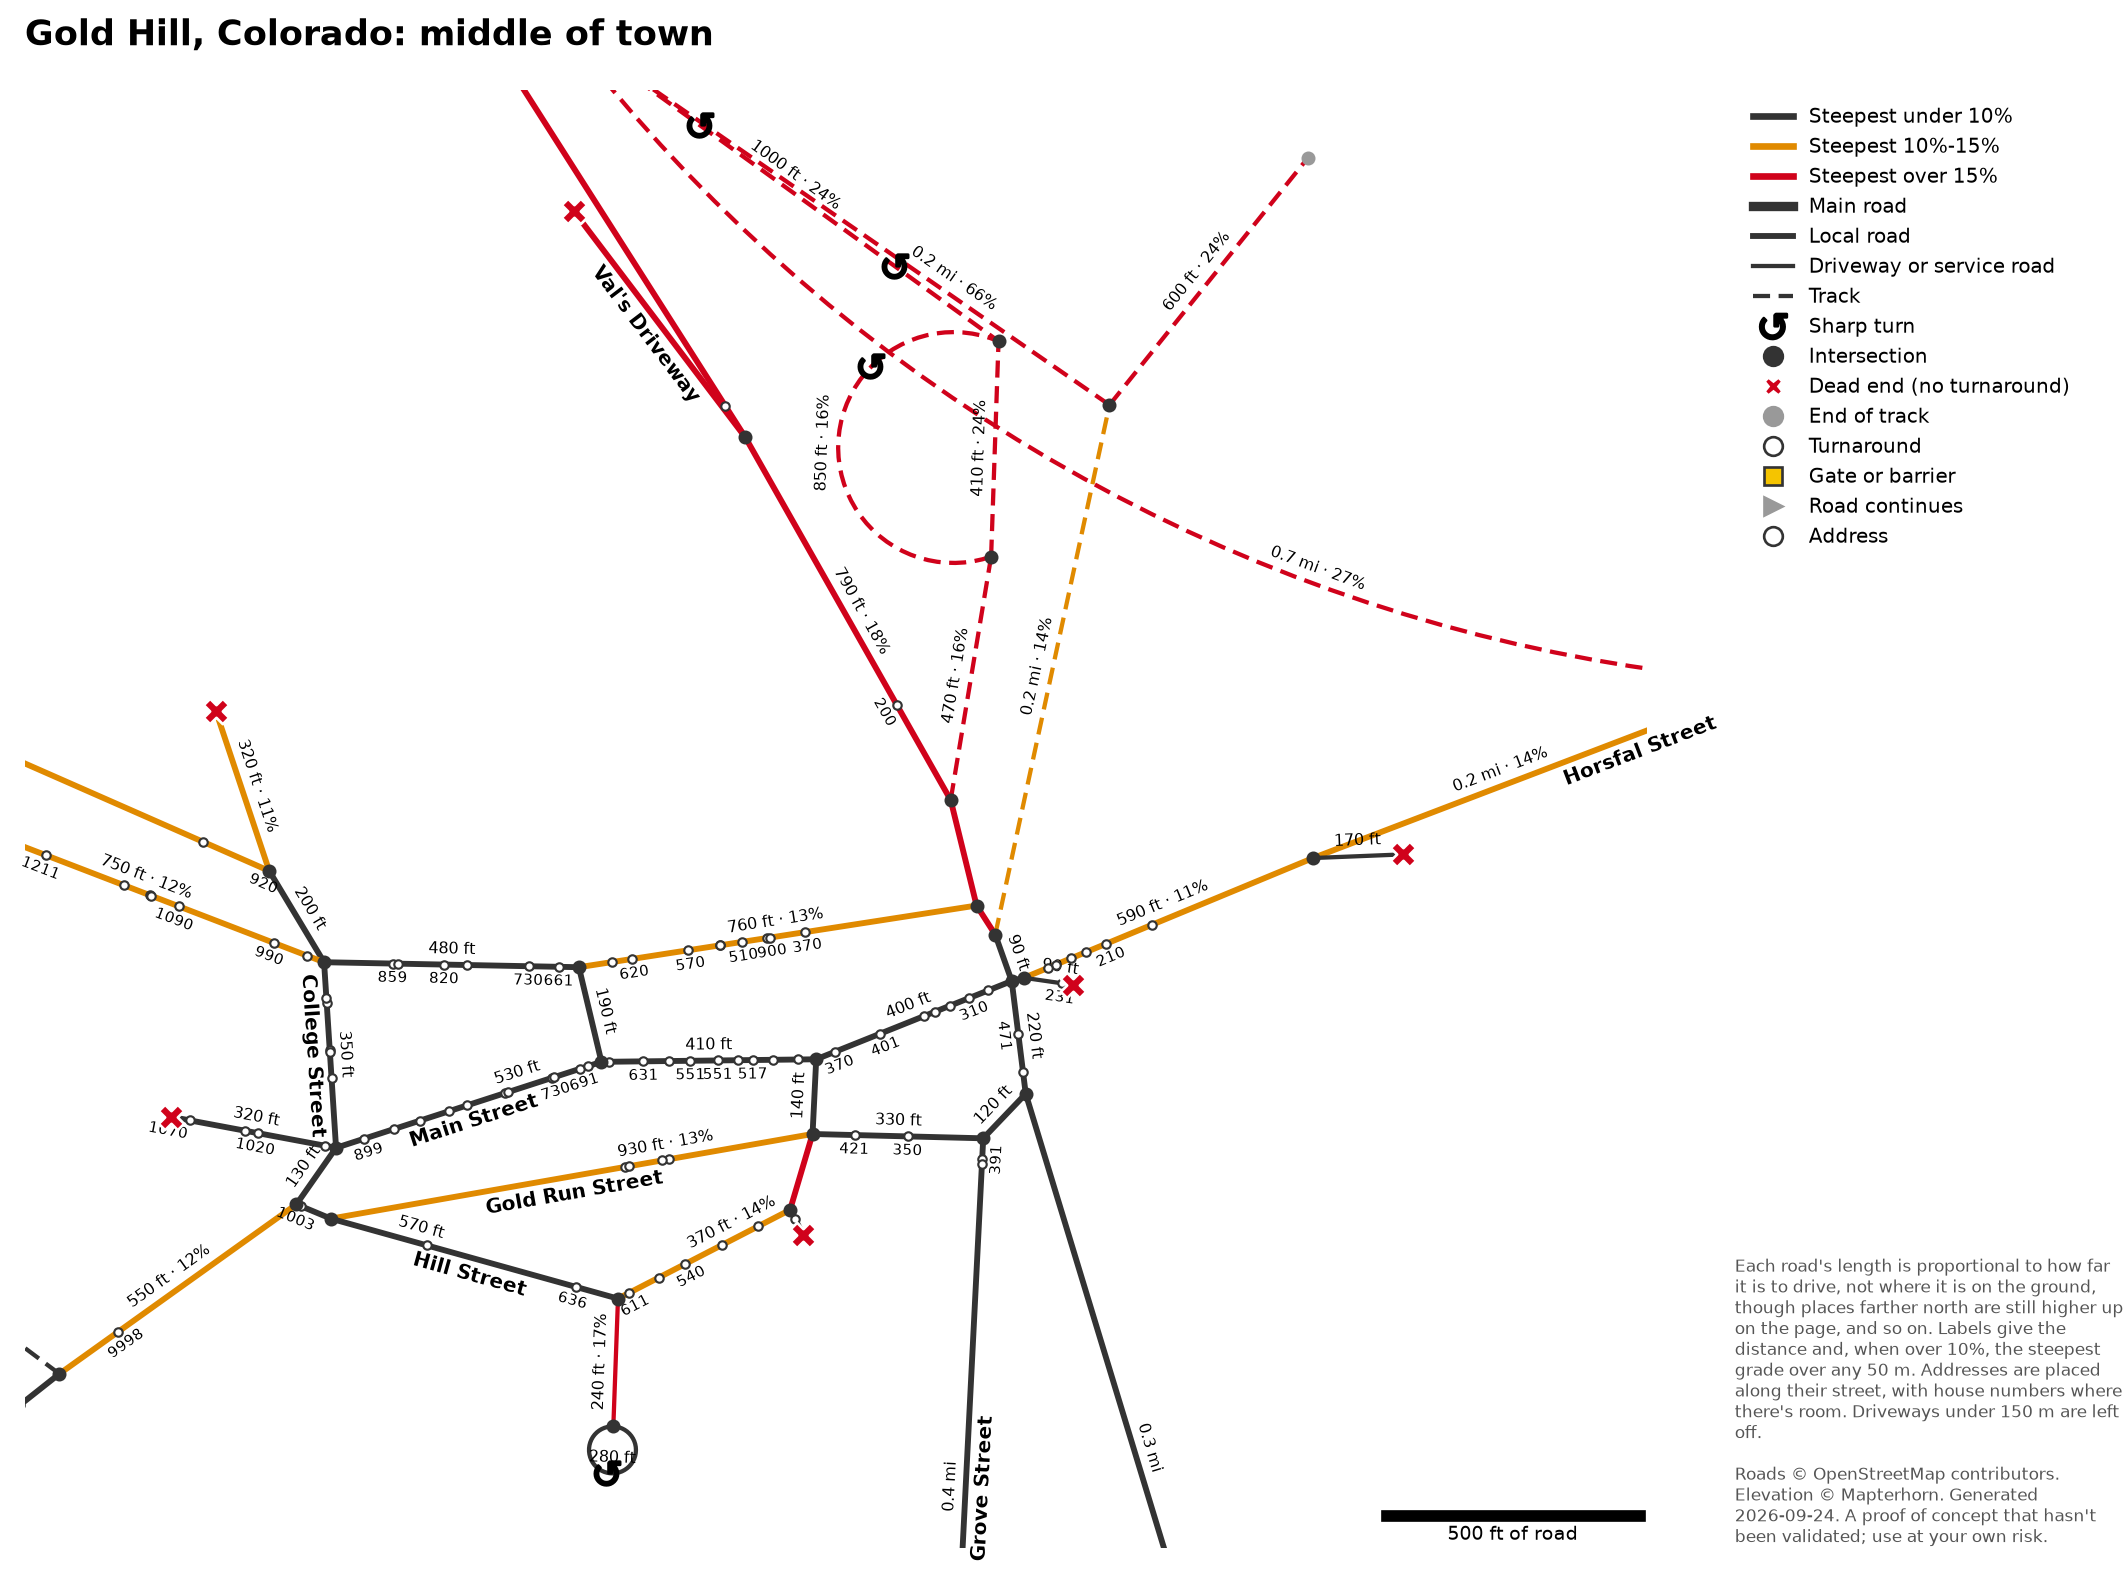

In [10]:
# the part of the diagram for intersections within this distance of CENTER on the ground
DETAIL_RADIUS_METERS = 400

near = np.array(
    [
        pos[n]
        for n, d in G.nodes(data=True)
        if CENTER_POINT.distance(Point(d["x"], d["y"])) <= DETAIL_RADIUS_METERS
    ]
)
(xmin, ymin), (xmax, ymax) = near.min(axis=0), near.max(axis=0)
margin = 0.1 * max(xmax - xmin, ymax - ymin)
draw(
    f"{PLACE_NAME}: middle of town",
    (xmin - margin, ymin - margin, xmax + margin, ymax + margin),
)
plt.show()